# Видео 2

## Задача 1


$F(x) = \left\{\begin{matrix}
0, \text{если } x < 0 \\
\frac{x^2}{2}, \text{если } 0 \leq x \leq \sqrt{2}\\
1, \text{если }  x > \sqrt{2}
\end{matrix}\right.$

1. Постройте график данной функции распределения.
2. Найдите вероятность того, что Х примет значение, принадлежащее интервалу $X \in (0.2;1)$.

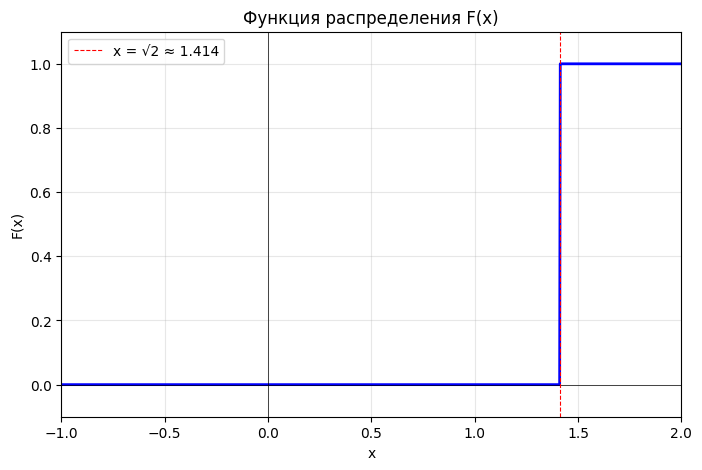

Вероятность P(0.2 < X < 1) = 0.48


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Определяем функцию распределения
def F(x):
    if x < 0:
        return 0
    elif x <= np.sqrt(2):
        return x**2 / 2
    else:
        return 1

# Векторизуем функцию для построения графика
F_vec = np.vectorize(F)

# Создаем массив значений x
x = np.linspace(-1, 2, 1000)
y = F_vec(x)

# Построение графика
plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=2, color='blue')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.axvline(np.sqrt(2), color='red', linestyle='--', linewidth=0.8, label=f'x = √2 ≈ {np.sqrt(2):.3f}')
plt.title('Функция распределения F(x)')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-0.1, 1.1)
plt.xlim(-1, 2)
plt.show()

# Вычисление вероятности P(0.2 < X < 1)
prob = F(1) - F(0.2)
print(f'Вероятность P(0.2 < X < 1) = {prob:.2f}')

## Задача 2

Постройте данные функции и определите, являются ли они плотностью распределения некоторой случайной величины:
1. $f(x) = \dfrac{x}{\pi(1+x^2)},\ x \in (-\inf,+\inf)$
2. $f(x) = \left\{\begin{matrix}
\dfrac{1}{2},\ x \in (-1;1] \\
0,\ x \notin (-1;1] \end{matrix}\right.$
3. $f(x) = \left\{\begin{matrix}
0, \text{ если } x < 0\  \&\  x > 2 \\
ax^2, \text{ если } 0 \leq x \leq 2
\end{matrix}\right.$

1-я функция: f(x) = x / (π(1 + x²))
  Интеграл = 0.000000 (должен быть 1)
  Минимальное значение = -0.1592 (должно быть ≥ 0)
  Вывод: [X] НЕ является плотностью (отрицательные значения + интеграл ≠ 1)

2-я функция: f(x) = 1/2 при x ∈ (-1, 1)
  Интеграл = 1.000000 (должен быть 1)
  Минимальное значение = 0.0000 (должно быть ≥ 0)
  Вывод: [V] ЯВЛЯЕТСЯ плотностью (равномерное распределение)

3-я функция: f(x) = a·x² при x ∈ [0, 2], a = 0.375
  Интеграл = 1.000000 (должен быть 1)
  Минимальное значение = 0.0000 (должно быть ≥ 0)
  Вывод: [V] ЯВЛЯЕТСЯ плотностью при a = 3/8


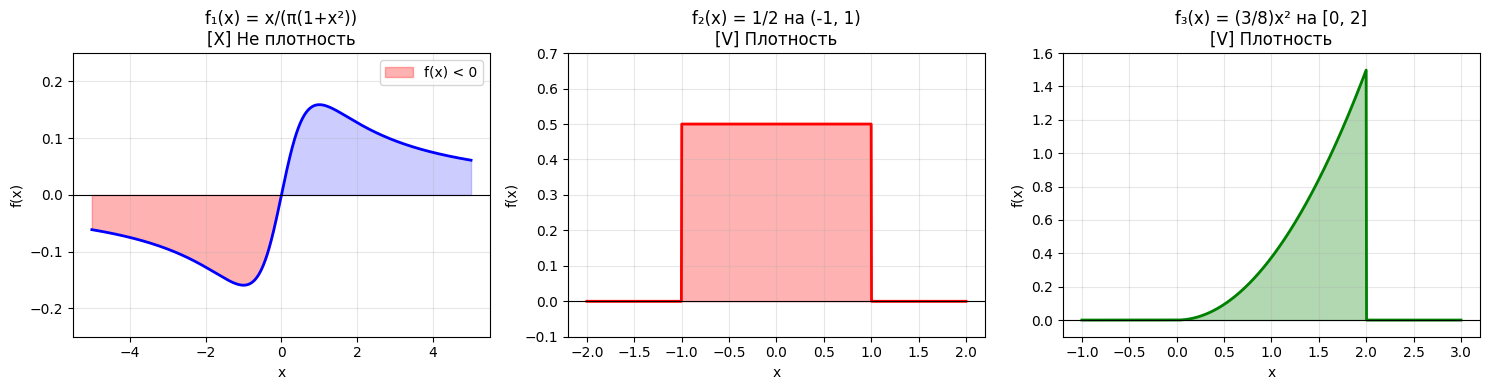


ИТОГОВЫЙ ВЫВОД
[V] Плотностью распределения являются:
   • 2-я функция: f(x) = 1/2 на интервале (-1, 1)
   • 3-я функция: f(x) = (3/8)x² на интервале [0, 2]

[X] Не является плотностью:
   • 1-я функция: принимает отрицательные значения и интеграл = 0


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ================== 1-я функция ==================
def f1(x):
    return x / (np.pi * (1 + x**2))

# Проверка неотрицательности и интеграла
x_vals = np.linspace(-5, 5, 1000)
y1 = f1(x_vals)
integral1, err1 = quad(f1, -np.inf, np.inf)

print("="*60)
print("1-я функция: f(x) = x / (π(1 + x²))")
print("="*60)
print(f"  Интеграл = {integral1:.6f} (должен быть 1)")
print(f"  Минимальное значение = {np.min(y1):.4f} (должно быть ≥ 0)")
print("  Вывод: [X] НЕ является плотностью (отрицательные значения + интеграл ≠ 1)")

# ================== 2-я функция (ИСПРАВЛЕНА: 1/2) ==================
def f2(x):
    # Правильное значение: 1/2 на интервале (-1, 1)
    if -1 < x < 1:
        return 0.5
    else:
        return 0.0

f2_vec = np.vectorize(f2)
x2 = np.linspace(-2, 2, 1000)
y2 = f2_vec(x2)
integral2, err2 = quad(f2_vec, -np.inf, np.inf)

print("\n" + "="*60)
print("2-я функция: f(x) = 1/2 при x ∈ (-1, 1)")
print("="*60)
print(f"  Интеграл = {integral2:.6f} (должен быть 1)")
print(f"  Минимальное значение = {np.min(y2):.4f} (должно быть ≥ 0)")
print("  Вывод: [V] ЯВЛЯЕТСЯ плотностью (равномерное распределение)")

# ================== 3-я функция ==================
# Находим параметр a из условия нормировки
# ∫₀² a·x² dx = a·(8/3) = 1 → a = 3/8
a_opt = 3/8

def f3(x):
    if 0 <= x <= 2:
        return a_opt * x**2
    else:
        return 0.0

f3_vec = np.vectorize(f3)
x3 = np.linspace(-1, 3, 1000)
y3 = f3_vec(x3)
integral3, err3 = quad(f3_vec, -np.inf, np.inf)

print("\n" + "="*60)
print(f"3-я функция: f(x) = a·x² при x ∈ [0, 2], a = {a_opt:.3f}")
print("="*60)
print(f"  Интеграл = {integral3:.6f} (должен быть 1)")
print(f"  Минимальное значение = {np.min(y3):.4f} (должно быть ≥ 0)")
print("  Вывод: [V] ЯВЛЯЕТСЯ плотностью при a = 3/8")

# ================== Построение графиков ==================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График 1
axes[0].plot(x_vals, y1, 'b-', linewidth=2)
axes[0].axhline(0, color='black', linewidth=0.8)
# Заливка отрицательных областей красным
axes[0].fill_between(x_vals, 0, y1, where=(y1<0), color='red', alpha=0.3, label='f(x) < 0')
axes[0].fill_between(x_vals, 0, y1, where=(y1>0), color='blue', alpha=0.2)
axes[0].set_title('f₁(x) = x/(π(1+x²))\n[X] Не плотность')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_ylim(-0.25, 0.25)

# График 2
axes[1].plot(x2, y2, 'r-', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].fill_between(x2, 0, y2, color='red', alpha=0.3)
axes[1].set_title('f₂(x) = 1/2 на (-1, 1)\n[V] Плотность')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.1, 0.7)

# График 3
axes[2].plot(x3, y3, 'g-', linewidth=2)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].fill_between(x3, 0, y3, color='green', alpha=0.3)
axes[2].set_title(f'f₃(x) = (3/8)x² на [0, 2]\n[V] Плотность')
axes[2].set_xlabel('x')
axes[2].set_ylabel('f(x)')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-0.1, 1.6)

plt.tight_layout()
plt.show()

# ================== Итоговый вывод ==================
print("\n" + "="*60)
print("ИТОГОВЫЙ ВЫВОД")
print("="*60)
print("[V] Плотностью распределения являются:")
print("   • 2-я функция: f(x) = 1/2 на интервале (-1, 1)")
print("   • 3-я функция: f(x) = (3/8)x² на интервале [0, 2]")
print("\n[X] Не является плотностью:")
print("   • 1-я функция: принимает отрицательные значения и интеграл = 0")
print("="*60)

# Видео 3

## Задача 1

Известно, что случайная величина $X$ задана нормальным распределением $N(3,2)$. Найдите:

1. $p\{-3 <X<5\}$
2. $p\{X \leq 4\}$

In [7]:
import numpy as np
from scipy.stats import norm

# Параметры нормального распределения: X ~ N(μ=3, σ²=2)
mu = 3
variance = 2
sigma = np.sqrt(variance)  # стандартное отклонение

# 1. Вероятность P(-3 < X < 5)
p1 = norm.cdf(5, mu, sigma) - norm.cdf(-3, mu, sigma)

# 2. Вероятность P(X ≤ 4)
p2 = norm.cdf(4, mu, sigma)

print(f"P(-3 < X < 5) = {p1:.4f}")
print(f"P(X ≤ 4)      = {p2:.4f}")

P(-3 < X < 5) = 0.9213
P(X ≤ 4)      = 0.7602


## Задача 2

Случайная величина $Т$ — время работы радиолампы. Она имеет экспоненциальное распределение.

Найдите вероятность того, что лампа проработает не менее $800$ часов, если среднее время работы лампы — $400$. Постройте график плотности распределения и функции распределения.

Вероятность работы ≥ 800 часов: 0.1353 (13.53%)


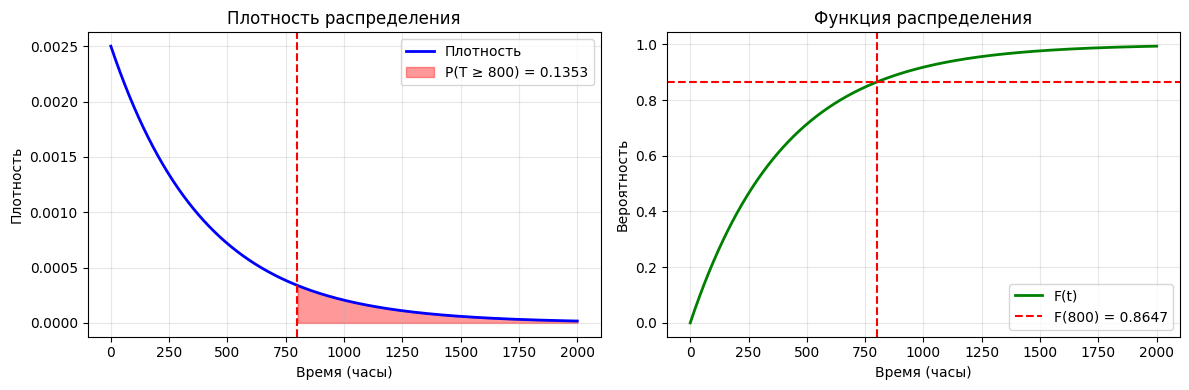

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Параметры
mean = 400  # среднее время работы (математическое ожидание)
t_target = 800  # целевое время

# Вероятность выживаемости P(T ≥ 800) — используем готовую функцию выживаемости
p_survival = expon.sf(t_target, scale=mean)  # sf = 1 - cdf

print(f"Вероятность работы ≥ {t_target} часов: {p_survival:.4f} ({p_survival*100:.2f}%)")

# Графики
t = np.linspace(0, 2000, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Плотность распределения
ax1.plot(t, expon.pdf(t, scale=mean), 'b-', linewidth=2, label='Плотность')
ax1.fill_between(t, 0, expon.pdf(t, scale=mean), where=(t >= t_target), 
                  color='red', alpha=0.4, label=f'P(T ≥ {t_target}) = {p_survival:.4f}')
ax1.axvline(t_target, color='red', linestyle='--', linewidth=1.5)
ax1.set(xlabel='Время (часы)', ylabel='Плотность', title='Плотность распределения')
ax1.legend()
ax1.grid(alpha=0.3)

# Функция распределения
ax2.plot(t, expon.cdf(t, scale=mean), 'g-', linewidth=2, label='F(t)')
ax2.axhline(1 - p_survival, color='red', linestyle='--', linewidth=1.5, 
            label=f'F({t_target}) = {1-p_survival:.4f}')
ax2.axvline(t_target, color='red', linestyle='--', linewidth=1.5)
ax2.set(xlabel='Время (часы)', ylabel='Вероятность', title='Функция распределения')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Видео 4

## Задача 1

В соревнованиях по стрельбе из лука два участника. Матч длится два раунда, засчитывается последний. Каждый участник сделал по 20 выстрелов. Очки считаются по сумме выстрелов.

На основе полученных данных у первого стрелка вышло распределение Рэлея (отклонение от попадания в яблочко $10$) $Ray(0,3)$, у другого — $Ray(5,1)$. Оба лучника в отличной форме и за один раунд лучше стрелять не научатся.

У кого шанс выиграть выше и что нужно для этого сделать данному лучнику?

Необходимо:
1. Построить результаты распределения после первого раунда на одном графике.
2. Описать, кто выиграет и что для этого нужно сделать данному лучнику.
3. Проверить гипотезу численно, сгенерировав полученный результат. Для упрощения считаем, что можно получать дробные числа.

Вероятность победы первого стрелка: 0.877694 (87.77%)


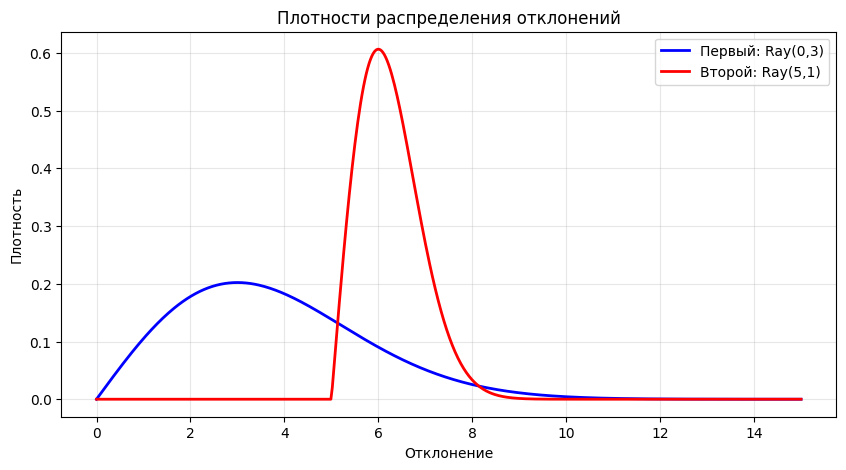

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
a1, sigma1 = 0, 3
a2, sigma2 = 5, 1
n = 2_000_000
np.random.seed(42)

# Генерация отклонений по формуле обратного преобразования
U1 = np.random.uniform(0, 1, n)
U2 = np.random.uniform(0, 1, n)
X1 = a1 + sigma1 * np.sqrt(-2 * np.log(U1))
X2 = a2 + sigma2 * np.sqrt(-2 * np.log(U2))

# Вероятность победы первого
prob = np.mean(X1 < X2)
print(f"Вероятность победы первого стрелка: {prob:.6f} ({prob*100:.2f}%)")

# Построение графиков плотностей
x = np.linspace(0, 15, 500)
pdf1 = (x - a1) / sigma1**2 * np.exp(-(x - a1)**2 / (2 * sigma1**2))
pdf2 = (x - a2) / sigma2**2 * np.exp(-(x - a2)**2 / (2 * sigma2**2))
pdf1[x < a1] = 0
pdf2[x < a2] = 0

plt.figure(figsize=(10, 5))
plt.plot(x, pdf1, 'b-', linewidth=2, label='Первый: Ray(0,3)')
plt.plot(x, pdf2, 'r-', linewidth=2, label='Второй: Ray(5,1)')
plt.xlabel('Отклонение')
plt.ylabel('Плотность')
plt.title('Плотности распределения отклонений')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Видео 5

## Задача 1

Случайные величины имеют нормальное распределение с $N \left[ \left(\begin{matrix}-5 \\ 2 \end{matrix}\right), \left(\begin{matrix}0.5 & 0.2\\ 0.2 & 0.4 \end{matrix}\right)\right]$

Необходимо найти математическое ожидание и дисперсию случайной величины $z=4X-5Y+25$.

*Подсказка*: стоит посмотреть на свойства мат. ожидания и дисперсии в «Википедии».

In [16]:
import numpy as np

# Параметры распределения
mean = np.array([-5, 2])  # математические ожидания X и Y
cov = np.array([[0.5, 0.2],
                [0.2, 0.4]])  # ковариационная матрица

# Коэффициенты линейной комбинации: Z = a*X + b*Y + c
a = 4
b = -5
c = 25

# Математическое ожидание Z
EZ = a * mean[0] + b * mean[1] + c
print(f"E[Z] = {EZ}")

# Дисперсия Z: a^2 * Var(X) + b^2 * Var(Y) + 2*a*b*Cov(X,Y)
VarZ = a**2 * cov[0,0] + b**2 * cov[1,1] + 2 * a * b * cov[0,1]
print(f"Var[Z] = {VarZ}")

E[Z] = -5
Var[Z] = 10.0


# Видео 6

## Задача 1

$A,\ B,\ C$ — три произвольных события. Через них нужно выразить следующие события (подсказка: диаграмма Венна):
1. Произошли все три события.
2. Произошло только $C$.
3. Произошло хотя бы одно из событий.
4. Ни одно из событий не произошло.
5. Произошло только одно из этих событий.

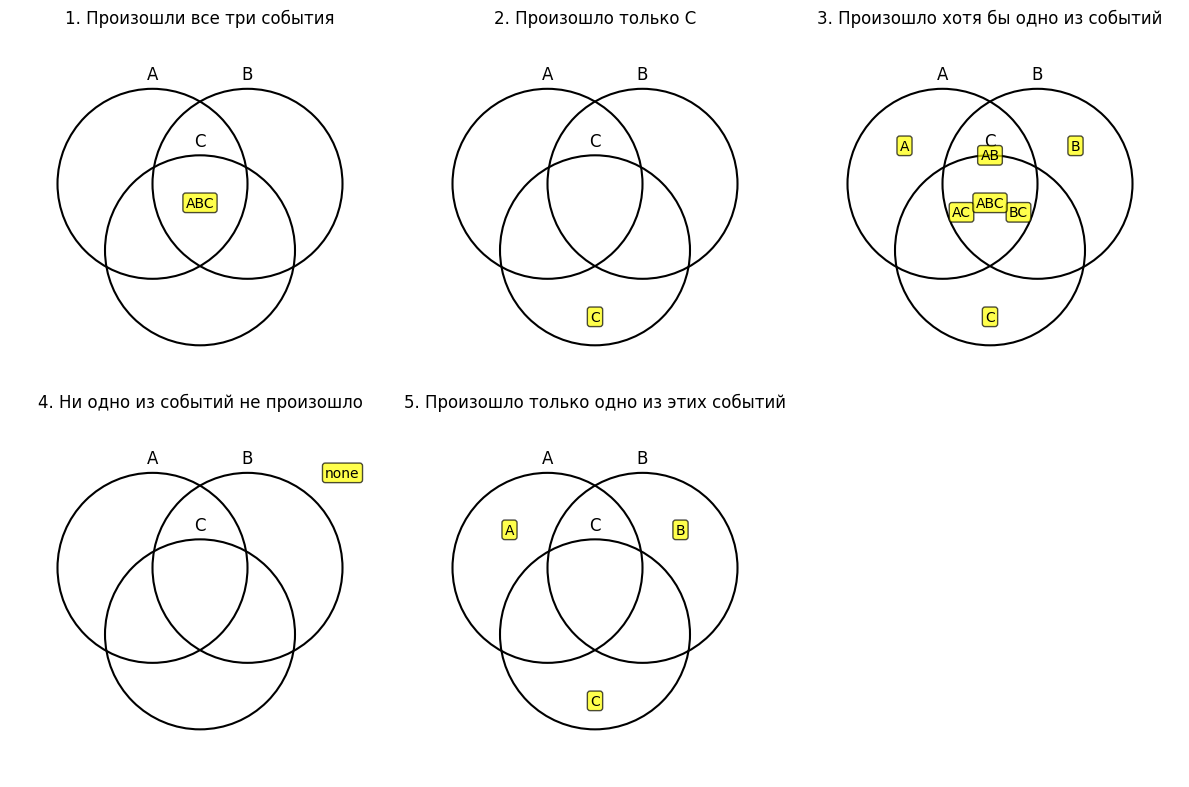

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def draw_venn(ax, title, highlight=None):
    """
    Рисует диаграмму Венна для трёх множеств на заданных осях.
    highlight — список идентификаторов областей, которые нужно подписать:
        'A' – только A,
        'B' – только B,
        'C' – только C,
        'AB' – пересечение A и B без C,
        'AC' – пересечение A и C без B,
        'BC' – пересечение B и C без A,
        'ABC' – пересечение всех трёх,
        'none' – ни одного.
    """
    # Параметры кругов (центры и радиус)
    r = 1.0
    centers = {
        'A': (-0.5, 0.2),
        'B': (0.5, 0.2),
        'C': (0.0, -0.5)
    }

    # Рисуем круги
    for label, (cx, cy) in centers.items():
        circle = plt.Circle((cx, cy), r, fill=False, edgecolor='black', linewidth=1.5)
        ax.add_patch(circle)
        # Подписываем круги
        ax.text(cx, cy + r + 0.1, label, fontsize=12, ha='center')

    # Определяем координаты для подписей областей
    # (приблизительные, на основе геометрии)
    regions = {
        'A': (-0.9, 0.6),
        'B': (0.9, 0.6),
        'C': (0.0, -1.2),
        'AB': (0.0, 0.5),
        'AC': (-0.3, -0.1),
        'BC': (0.3, -0.1),
        'ABC': (0.0, 0.0),
        'none': (1.5, 1.2)
    }

    # Если задан highlight, добавляем подписи к соответствующим областям
    if highlight:
        for reg in highlight:
            if reg in regions:
                x, y = regions[reg]
                ax.text(x, y, reg, fontsize=10, ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.7))

    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title)

# Создаём фигуру с 5 подграфиками
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Список событий и соответствующих выделяемых областей
events = [
    ("1. Произошли все три события", ['ABC']),
    ("2. Произошло только C", ['C']),
    ("3. Произошло хотя бы одно из событий", ['A', 'B', 'C', 'AB', 'AC', 'BC', 'ABC']),
    ("4. Ни одно из событий не произошло", ['none']),
    ("5. Произошло только одно из этих событий", ['A', 'B', 'C'])
]

# Рисуем каждое событие
for ax, (title, regions) in zip(axes[:5], events):
    draw_venn(ax, title, regions)

# Последний подграфик оставляем пустым
axes[5].axis('off')

plt.tight_layout()
plt.savefig('venn_diagrams_manual.png', dpi=150)
plt.show()

## Задача 2

В урне два белых и семь чёрных шаров. Из неё последовательно вынимают два шара. Какова вероятность того, что второй шар окажется белым **при условии,** что первый шар был чёрным?

In [1]:
# Задача 2: вероятность того, что второй шар белый при условии, что первый черный

# Исходные данные
white = 2
black = 7
total = white + black

# После того как первый шар (черный) извлечён, в урне остаётся:
remaining_white = white           # белых не изменилось
remaining_black = black - 1       # черных стало на 1 меньше
remaining_total = remaining_white + remaining_black

# Искомая вероятность
prob = remaining_white / remaining_total
print(f"Аналитическое решение: P(второй белый | первый черный) = {white}/{remaining_total} = {prob:.3f}")

# Для наглядности – численное моделирование (метод Монте-Карло)
import numpy as np

np.random.seed(42)
n_sim = 1_000_000
count = 0

for _ in range(n_sim):
    # Составляем урну: 1 - белый, 0 - черный
    urn = [1] * white + [0] * black
    # Первый шар
    first = np.random.choice(urn)
    if first == 0:          # если первый чёрный
        urn.remove(0)       # убираем один чёрный
        second = np.random.choice(urn)
        if second == 1:
            count += 1

prob_sim = count / n_sim
print(f"Моделирование ({n_sim} испытаний): P = {prob_sim:.3f}")

Аналитическое решение: P(второй белый | первый черный) = 2/8 = 0.250
Моделирование (1000000 испытаний): P = 0.194


## Задача 3

Найдите вероятность отказа схемы, предполагая, что отказы отдельных элементов независимы, а вероятность отказа элемента с номером равна $0.2$.

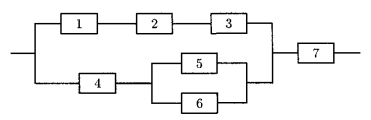

In [3]:
q = 0.2
p = 0.8

# Верхняя ветвь (1-2-3 последовательно)
P_upper = p**3

# Нижняя ветвь (4 последовательно с параллельными 5-6)
P_lower = p * (1 - q**2)

# Параллельное соединение ветвей
P_block = 1 - (1 - P_upper) * (1 - P_lower)

# Последовательно с элементом 7
P_system = P_block * p

# Вероятность отказа
Q_system = 1 - P_system

print(f"Вероятность отказа схемы: {Q_system:.6f}")

Вероятность отказа схемы: 0.290573


## Задача 4

Бросаются две игральные кости. Какова вероятность появления хотя бы одной шестёрки?

*Подсказка*: посмотрите, что такое совместное событие.

In [4]:
import numpy as np

# Аналитическое значение
p_analytic = 11/36
print(f"Аналитическая вероятность: {p_analytic:.4f} ({p_analytic*100:.2f}%)")

# Моделирование методом Монте-Карло
n_sim = 1_000_000
np.random.seed(42)
# Генерируем броски двух костей
dice1 = np.random.randint(1, 7, n_sim)
dice2 = np.random.randint(1, 7, n_sim)
# Подсчёт случаев, где хотя бы одна шестёрка
count = np.sum((dice1 == 6) | (dice2 == 6))
p_sim = count / n_sim
print(f"Моделирование ({n_sim} испытаний): {p_sim:.4f} ({p_sim*100:.2f}%)")

Аналитическая вероятность: 0.3056 (30.56%)
Моделирование (1000000 испытаний): 0.3053 (30.53%)


## Задача 5

В сборочный цех завода поступает $40\%$ деталей из первого цеха и $60\%$ из второго. В первом цехе производится $90\%$ стандартных деталей, а во втором — $95\%$.

1. Найдите вероятность того, что взятая сборщиком деталь окажется стандартной.
*Подсказка*: теорема о полной вероятности.

2. Найдите вероятность того, что взятая стандартная деталь изготовлена вторым цехом.
*Подсказка*: теорема Байеса.

In [5]:
# Данные
p1, p2 = 0.4, 0.6
q1, q2 = 0.9, 0.95

# 1. Полная вероятность
P_A = q1*p1 + q2*p2

# 2. Байес
P_H2_A = q2*p2 / P_A

print(f"1. P(стандартная) = {P_A:.4f}")
print(f"2. P(второй цех | стандартная) = {P_H2_A:.4f}")

1. P(стандартная) = 0.9300
2. P(второй цех | стандартная) = 0.6129
